# Customer Satisfaction Risk Modeling

This notebook tests whether information available at the time of purchase can be used to identify orders at elevated risk of receiving a low customer review. The initial model predicts the risk of a **1–2-star review** and evaluates whether predicted probabilities can meaningfully rank orders for potential intervention.

If order-level risk can be identified reliably, predicted risk can later be aggregated by seller and combined with seller-level business value to support seller prioritization.

In [1]:
import pandas as pd

date_cols = [
    "shipping_limit_date",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

olist_df = pd.read_csv(
    "../01_data/preprocessed/olist_order_item_baseline.csv",
    parse_dates=date_cols,
)

olist_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  str           
 3   seller_id                      112650 non-null  str           
 4   shipping_limit_date            112650 non-null  datetime64[us]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    112650 non-null  str           
 8   order_status                   112650 non-null  str           
 9   order_purchase_timestamp       112650 non-null  datetime64[us]
 10  order_approved_at              112635 non-null  datetime64[us]
 11  order_deliv

### Construct Order-Level Modeling Dataset

The source data contains one row per order item, while the model will predict risk at the **order level**. Item-level data are therefore aggregated to one row per order while preserving purchase-time information about order value, products, sellers, categories, customer location, and payment characteristics.

Product dimensions are excluded because aggregating individual item dimensions would not meaningfully represent the final shipment. Seller identity is also excluded as a predictor so the initial model learns from order characteristics rather than individual seller history.

Orders without a review are excluded because their outcome is unknown. Two candidate targets are retained for comparison:

- **`low_review_2`**: 1–2 stars
- **`low_review_3`**: 1–3 stars

Only information available at or near the time of purchase will be used as predictors to avoid post-order leakage.

In [2]:
# Construct order-level modeling dataset

# 1. Aggregate item-level order characteristics
order_features = (
    olist_df.groupby("order_id")
    .agg(
        merchandise_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count"),
        unique_product_count=("product_id", "nunique"),
        unique_seller_count=("seller_id", "nunique"),
        total_product_weight_g=("product_weight_g", "sum"),
        avg_product_photos=("product_photos_qty", "mean"),
        avg_product_name_length=("product_name_lenght", "mean"),
        avg_product_description_length=(
            "product_description_lenght",
            "mean",
        ),
        unique_category_count=("product_category_name", "nunique"),
    )
    .reset_index()
)

# Freight as a share of the total order value
order_features["freight_share"] = (
    order_features["freight_value"]
    / (
        order_features["merchandise_value"]
        + order_features["freight_value"]
    )
)


# 2. Create order-level product category indicators
category_data = olist_df[
    ["order_id", "product_category_name"]
].copy()

category_data["product_category_name"] = (
    category_data["product_category_name"]
    .fillna("unknown")
)

category_features = pd.crosstab(
    category_data["order_id"],
    category_data["product_category_name"],
)

category_features = (category_features > 0).astype(int)

category_features.columns = [
    f"category_{col}" for col in category_features.columns
]

category_features = category_features.reset_index()


# 3. Retain fields that are constant within each order
order_level_cols = [
    "order_id",
    "customer_unique_id",
    "customer_state",
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "primary_payment_type",
    "payment_count",
    "payment_type_count",
    "payment_installments",
    "payment_value",
    "last_review_score",
]

order_info = (
    olist_df[order_level_cols]
    .drop_duplicates("order_id")
    .copy()
)


# 4. Create cross-state fulfillment indicator
# An order is cross-state if at least one seller is in a different
# state from the customer.
cross_state = (
    olist_df.assign(
        cross_state_item=(
            olist_df["seller_state"] != olist_df["customer_state"]
        ).astype(int)
    )
    .groupby("order_id")["cross_state_item"]
    .max()
    .rename("cross_state")
    .reset_index()
)


# 5. Combine order-level features
order_df = (
    order_features
    .merge(category_features, on="order_id", how="left")
    .merge(order_info, on="order_id", how="left")
    .merge(cross_state, on="order_id", how="left")
)


# 6. Engineer promised delivery window available at order placement
order_df["promised_delivery_days"] = (
    order_df["order_estimated_delivery_date"]
    - order_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400


# 7. Keep only orders with an observed review outcome
order_df = (
    order_df
    .dropna(subset=["last_review_score"])
    .copy()
)


# 8. Create candidate binary review targets
order_df["low_review_2"] = (
    order_df["last_review_score"] <= 2
).astype(int)

order_df["low_review_3"] = (
    order_df["last_review_score"] <= 3
).astype(int)


#9. Reset index for order-level dataframe
order_df = (
    order_df
    .dropna(subset=["last_review_score"])
    .reset_index(drop=True)
    .copy()
)

# 10. Check resulting modeling dataset
print(f"Shape: {order_df.shape}")

print("\nTarget prevalence:")
print(
    order_df[["low_review_2", "low_review_3"]]
    .mean()
    .rename("prevalence")
)

print("\nMissing values:")
print(
    order_df.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

Shape: (97917, 100)

Target prevalence:
low_review_2    0.141885
low_review_3    0.224404
Name: prevalence, dtype: float64

Missing values:
avg_product_photos                1379
avg_product_name_length           1379
avg_product_description_length    1379
primary_payment_type                 1
payment_count                        1
payment_type_count                   1
payment_installments                 1
payment_value                        1
dtype: int64


#### Missing Payment Data

One order has no recorded payment information. Because payment characteristics are included as purchase-time predictors and only one order is affected, this order is excluded from the modeling dataset.

In [3]:
# Remove the single order with no payment information
order_df = (
    order_df
    .dropna(subset=["primary_payment_type"])
    .reset_index(drop=True)
)

In [4]:
product_metadata_cols = [
    "avg_product_photos",
    "avg_product_name_length",
    "avg_product_description_length",
]

order_df[product_metadata_cols].isna().value_counts()

avg_product_photos  avg_product_name_length  avg_product_description_length
False               False                    False                             96537
True                True                     True                               1379
Name: count, dtype: int64

The three product-listing features are missing together for 1,379 orders, indicating a common missing-product-metadata pattern rather than isolated missing values. A binary `missing_product_metadata` indicator is retained, while the numeric features will be median-imputed within the modeling pipeline.

In [5]:
# Flag orders with missing product metadata
order_df["missing_product_metadata"] = (
    order_df["avg_product_photos"].isna()
).astype(int)

#### Payment Feature Audit

Payment variables are reviewed for their distributions and potential redundancy before finalizing the predictor set.

In [6]:
payment_corr_cols = [
    "merchandise_value",
    "freight_value",
    "payment_value",
    "payment_count",
    "payment_type_count",
    "payment_installments",
]

order_df[payment_corr_cols].corr().round(3)

,merchandise_value,freight_value,payment_value,payment_count,payment_type_count,payment_installments
merchandise_value,1.000,0.412,0.996,0.001,-0.008,0.315
freight_value,0.412,1.000,0.492,0.006,-0.003,0.199
payment_value,0.996,0.492,1.000,0.002,-0.008,0.321
payment_count,0.001,0.006,0.002,1.000,0.541,-0.044
payment_type_count,-0.008,-0.003,-0.008,0.541,1.000,-0.043
payment_installments,0.315,0.199,0.321,-0.044,-0.043,1.000


`payment_value` is effectively redundant with the combined merchandise and freight value of the order and is therefore excluded from the predictor set. The remaining payment features are retained because they represent distinct aspects of the customer's payment behavior.

#### Purchase Timing Features

Purchase month and day of week are extracted from the order timestamp to capture potential seasonal and weekly patterns using information available at the time of purchase.

In [7]:
# Create purchase-time calendar features
order_df["purchase_month"] = (
    order_df["order_purchase_timestamp"].dt.month
)

order_df["purchase_day_of_week"] = (
    order_df["order_purchase_timestamp"].dt.dayofweek
)

### Define Modeling Features

Predictors are restricted to information available at or near the time of purchase. Identifiers, raw timestamps, the redundant `payment_value` field, and review-derived outcome variables are explicitly excluded from modeling.

In [8]:
# Define baseline model features

excluded_features = [
    "order_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "payment_value",
    "last_review_score",
    "low_review_2",
    "low_review_3",
]

numeric_features = [
    "merchandise_value",
    "freight_value",
    "item_count",
    "unique_product_count",
    "unique_seller_count",
    "total_product_weight_g",
    "avg_product_photos",
    "avg_product_name_length",
    "avg_product_description_length",
    "unique_category_count",
    "freight_share",
    "payment_count",
    "payment_type_count",
    "payment_installments",
    "promised_delivery_days",
]

categorical_features = [
    "customer_state",
    "primary_payment_type",
    "purchase_month",
    "purchase_day_of_week",
]

# Identify multi-hot product category indicators
product_category_features = [
    col for col in order_df.columns
    if col.startswith("category_")
]

binary_features = [
    "cross_state",
    "missing_product_metadata",
    *product_category_features,
]

feature_cols = (
    numeric_features
    + categorical_features
    + binary_features
)

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Binary features: {len(binary_features)}")
print(f"Total baseline features: {len(feature_cols)}")

set(feature_cols) - set(order_df.columns)

Numeric features: 15
Categorical features: 4
Binary features: 76
Total baseline features: 95


set()

### Train/Test Split

The data are split into 80% training and 20% holdout test sets, stratified to preserve the low-review rate. Model development and tuning will use cross-validation within the training set, while the test set is reserved for evaluating performance on unseen orders.

In [9]:
from sklearn.model_selection import train_test_split

# Define predictors and target
X = order_df[feature_cols].copy()
y = order_df["low_review_2"].copy()

# Reserve 20% as the final test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    stratify=y,
)

print(
    f"Training Records: {len(X_train):,} "
    f"({y_train.mean():.2%} low review)"
)
print(
    f"Test Records: {len(X_test):,} "
    f"({y_test.mean():.2%} low review)"
)

Training Records: 78,332 (14.19% low review)
Test Records: 19,584 (14.19% low review)


### Preprocessing

Numeric features are median-imputed and standardized, with imputation parameters learned from the training data. Categorical features are one-hot encoded, while existing binary indicators are passed through unchanged.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
)

# Use stratified folds to preserve the target distribution during CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1,
)

### Baseline Logistic Regression

Logistic regression is used as an interpretable baseline for ranking orders by low-review risk. Because only about 14% of reviewed orders receive a 1–2-star review, both standard and class-balanced logistic regression are evaluated to determine whether class weighting improves identification of higher-risk orders.

Models are tuned using 5-fold cross-validation and **average precision**, which is more informative than accuracy for evaluating ranking performance with an imbalanced target.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logit_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
            ),
        ),
    ]
)

balanced_logit_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
            ),
        ),
    ]
)

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

logit_grid = GridSearchCV(
    estimator=logit_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
)

balanced_logit_grid = GridSearchCV(
    estimator=balanced_logit_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
)

logit_grid.fit(X_train, y_train)
balanced_logit_grid.fit(X_train, y_train)

print("Standard logistic:")
print("Best parameters:", logit_grid.best_params_)
print("Best CV AP:", round(logit_grid.best_score_, 4))

print("\nBalanced logistic:")
print("Best parameters:", balanced_logit_grid.best_params_)
print("Best CV AP:", round(balanced_logit_grid.best_score_, 4))

Standard logistic:
Best parameters: {'model__C': 0.01}
Best CV AP: 0.2514

Balanced logistic:
Best parameters: {'model__C': 0.01}
Best CV AP: 0.2506


Both models selected `C = 0.01`, indicating stronger regularization than the default logistic regression setting. Class weighting did not improve cross-validated average precision, so the standard logistic regression model is retained as the baseline model.

### Holdout Evaluation

The selected logistic regression model is evaluated on the 20% holdout set to determine whether its ranking performance generalizes to unseen orders.

In [13]:
best_logit = logit_grid.best_estimator_

test_proba = best_logit.predict_proba(X_test)[:, 1]

In [14]:
from sklearn.metrics import average_precision_score

test_ap = average_precision_score(y_test, test_proba)
test_baseline = y_test.mean()

print(f"Test baseline: {test_baseline:.4f}")
print(f"Test average precision: {test_ap:.4f}")

Test baseline: 0.1419
Test average precision: 0.2518


The holdout average precision of **0.2518** is substantially above the **0.1419** low-review prevalence and closely matches the cross-validated training result of 0.2514. This suggests that the baseline model's ranking performance generalizes to unseen orders.

#### Cumulative Lift and Capture

Because the intended use is to prioritize a limited subset of higher-risk orders, model performance is evaluated at several targeting depths. Orders are ranked from highest to lowest predicted risk, and each threshold measures the share of low reviews captured and the lift relative to the overall low-review rate.

In [15]:
lift_df = pd.DataFrame(
    {
        "actual": y_test.to_numpy(),
        "predicted_probability": test_proba,
    }
).sort_values(
    "predicted_probability",
    ascending=False,
)

baseline_rate = lift_df["actual"].mean()
total_low_reviews = lift_df["actual"].sum()

lift_results = []

for pct in [0.05, 0.10, 0.20, 0.30]:
    n_targeted = int(len(lift_df) * pct)
    targeted = lift_df.head(n_targeted)

    low_reviews_captured = targeted["actual"].sum()
    targeted_rate = targeted["actual"].mean()

    lift_results.append(
        {
            "targeted_pct": pct,
            "orders_targeted": n_targeted,
            "low_reviews_captured": low_reviews_captured,
            "capture_rate": low_reviews_captured / total_low_reviews,
            "targeted_low_review_rate": targeted_rate,
            "lift": targeted_rate / baseline_rate,
        }
    )

test_lift_results = pd.DataFrame(lift_results)

test_lift_results.round(3)

,targeted_pct,orders_targeted,low_reviews_captured,capture_rate,targeted_low_review_rate,lift
0,0.05,979,383,0.138,0.391,2.757
1,0.10,1958,647,0.233,0.330,2.329
2,0.20,3916,1012,0.364,0.258,1.821
3,0.30,5875,1303,0.469,0.222,1.563


The model concentrates low-review outcomes in the highest-risk orders. Targeting the top **10%** of orders identifies a group with a **33.0% low-review rate**, compared with **14.2% overall**, corresponding to **2.33× lift** and capturing **23.3% of all low reviews** in the holdout set.

This suggests that the model may be useful as a prioritization tool even though it does not identify every eventual low-review order.

In [16]:
decile_df = pd.DataFrame(
    {
        "actual": y_test.to_numpy(),
        "predicted_probability": test_proba,
    }
)

# Decile 1 = highest predicted risk
decile_df["risk_decile"] = (
    pd.qcut(
        decile_df["predicted_probability"],
        q=10,
        labels=False,
        duplicates="drop",
    )
    + 1
)

decile_df["risk_decile"] = 11 - decile_df["risk_decile"]

baseline_rate = decile_df["actual"].mean()

decile_lift = (
    decile_df.groupby("risk_decile", as_index=False)
    .agg(
        orders=("actual", "size"),
        low_reviews=("actual", "sum"),
        low_review_rate=("actual", "mean"),
    )
)

decile_lift["lift"] = (
    decile_lift["low_review_rate"] / baseline_rate
)

decile_lift.round(3)

,risk_decile,orders,low_reviews,low_review_rate,lift
0,1,1959,647,0.330,2.327
1,2,1958,365,0.186,1.314
2,3,1958,291,0.149,1.047
3,4,1959,242,0.124,0.871
4,5,1958,255,0.130,0.918
5,6,1958,221,0.113,0.795
6,7,1959,211,0.108,0.759
7,8,1958,187,0.096,0.673
8,9,1958,189,0.097,0.680
9,10,1959,171,0.087,0.615


#### Lift by Risk Decile

To visualize how risk is distributed across the full ranking, holdout orders are divided into ten equal-sized groups based on predicted probability. Decile 1 contains the highest-risk orders and Decile 10 the lowest-risk orders.

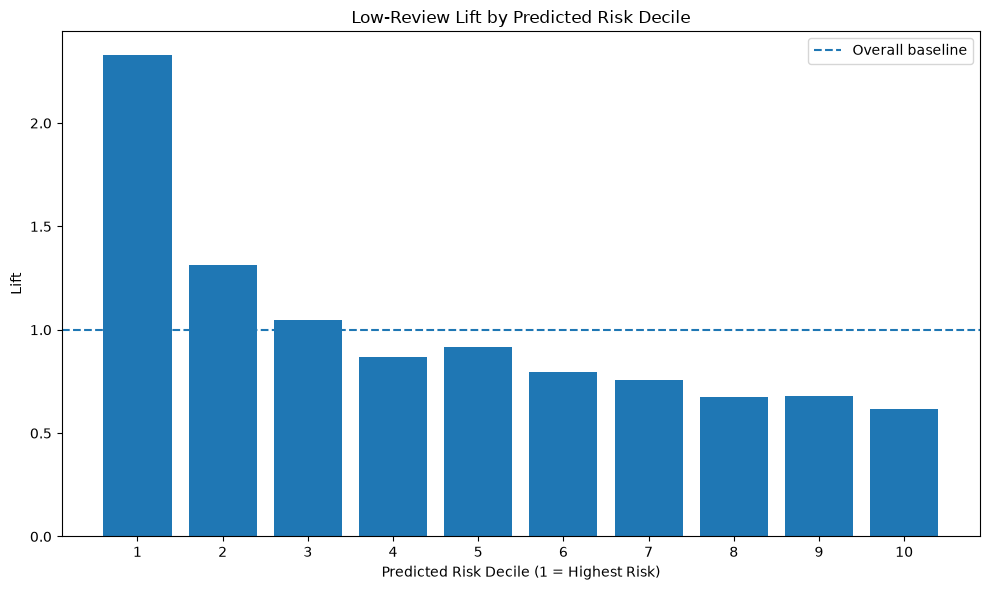

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    decile_lift["risk_decile"].astype(str),
    decile_lift["lift"],
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Overall baseline",
)

plt.xlabel("Predicted Risk Decile (1 = Highest Risk)")
plt.ylabel("Lift")
plt.title("Low-Review Lift by Predicted Risk Decile")
plt.legend()
plt.tight_layout()
plt.show()

The highest-risk decile has a **33.0% low-review rate**, corresponding to **2.33× lift** over the overall rate of 14.2%. Lift declines substantially across lower-risk deciles, indicating that the model meaningfully concentrates dissatisfied customers near the top of its ranking.

These baseline results support continuing to develop the order-risk approach and evaluating how predicted risk can be aggregated to support seller-level prioritization.